<a href="https://colab.research.google.com/github/suzetteabascal10-byte/Simulacion-I/blob/main/3p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##tecnicas de remuestreo
El programa inicia un ciclo que se repetirá. En cada vuelta, el sistema simula los 12 se saca uno, se registra cuál fue y lo vuelve a meter a la muestra. Repite este sorteo 12 veces hasta armar una nueva lista del mismo tamaño.

El efecto del reemplazo: Debido a que los números se regresan a la muestra, algunos numeros pueden volver a salir y otros no pueden salir ni una vez.

El cálculo del promedio simulado: Cada vez que el programa termina de armar una de estas simulaciones se calcula su promedio.
En jackknife El programa realiza un recorrido exacto de 12 pasos. En el primer paso, oculta el primer número de la lista y calcula el promedio con los 11 números que quedan visibles y asi con los demas datos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
datos = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])
n = len(datos)
media_original = np.mean(datos)

np.random.seed(42)
B = 2000
medias_bootstrap = np.zeros(B)

for i in range(B):
    muestra_bs = np.random.choice(datos, size=n, replace=True)
    medias_bootstrap[i] = np.mean(muestra_bs)

se_bootstrap = np.std(medias_bootstrap, ddof=1)
sesgo_bootstrap = np.mean(medias_bootstrap) - media_original
ic_percentil = np.percentile(medias_bootstrap, [2.5, 97.5])

medias_jackknife = np.zeros(n)

for i in range(n):
    muestra_jk = np.delete(datos, i)
    medias_jackknife[i] = np.mean(muestra_jk)

sesgo_jackknife = (n - 1) * (np.mean(medias_jackknife) - media_original)
se_jackknife = np.sqrt(((n - 1) / n) * np.sum((medias_jackknife - np.mean(medias_jackknife)) ** 2))


RESULTADOS DE TÉCNICAS DE REMUESTREO
Muestra original: [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
Media muestral real: 40.0

MÉTODO BOOTSTRAP (B = 2000 muestras)
Error Estándar (SE): 0.8565
Sesgo estimado: -0.0563
Intervalo de Confianza (95% Percentil): [ 38.25 , 41.6667 ]
MÉTODO JACKKNIFE (n = 12 submuestras)
Error Estándar (SE): 0.9129
Sesgo estimado: 0.0


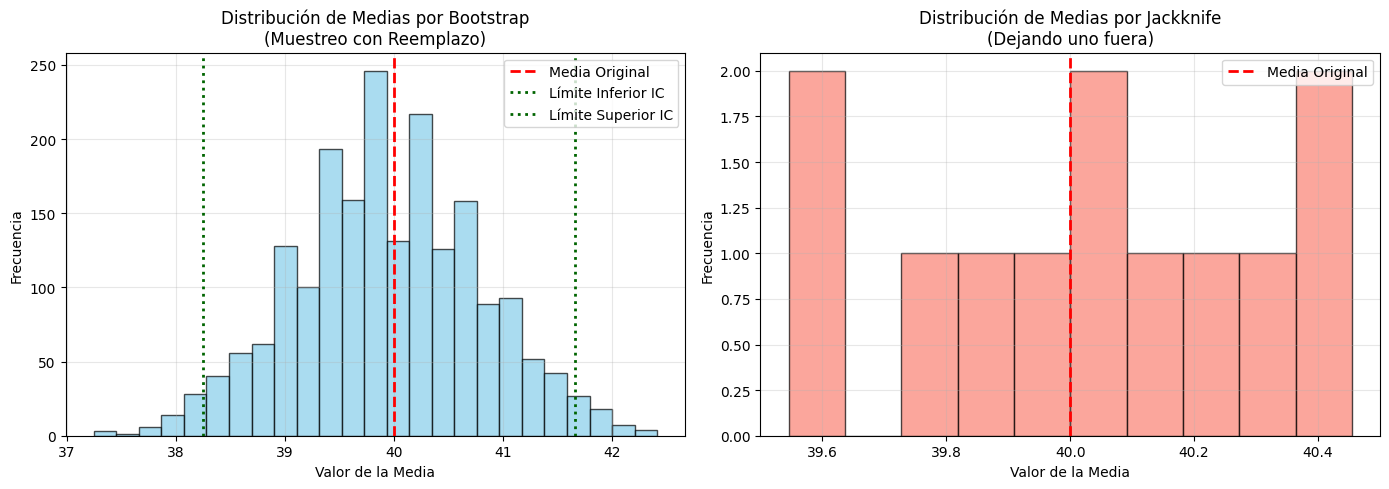

In [ ]:
print("RESULTADOS DE TÉCNICAS DE REMUESTREO")
print("Muestra original:", datos.tolist())
print("Media muestral real:", round(media_original, 4))
print()

print("MÉTODO BOOTSTRAP (B = 2000 muestras)")
print("Error Estándar (SE):", round(se_bootstrap, 4))
print("Sesgo estimado:", round(sesgo_bootstrap, 4))
print("Intervalo de Confianza (95% Percentil): [", round(ic_percentil[0], 4), ",", round(ic_percentil[1], 4), "]")

print("MÉTODO JACKKNIFE (n = 12 submuestras)")
print("Error Estándar (SE):", round(se_jackknife, 4))
print("Sesgo estimado:", round(sesgo_jackknife, 4))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(medias_bootstrap, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(media_original, color='red', linestyle='--', linewidth=2, label="Media Original")
plt.axvline(ic_percentil[0], color='darkgreen', linestyle=':', linewidth=2, label="Límite Inferior IC")
plt.axvline(ic_percentil[1], color='darkgreen', linestyle=':', linewidth=2, label="Límite Superior IC")
plt.title("Distribución de Medias por Bootstrap\n(Muestreo con Reemplazo)")
plt.xlabel("Valor de la Media")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(medias_jackknife, bins=10, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(media_original, color='red', linestyle='--', linewidth=2, label="Media Original")
plt.title("Distribución de Medias por Jackknife\n(Dejando uno fuera)")
plt.xlabel("Valor de la Media")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Gráfica de Bootstrap: Genera un gráfico de barras con las 2000 medias calculadas. Sobre ella se trazan líneas verticale dónde está la media original de la clase y entre qué límites se encuentra nuestro intervalo de confianza.

Gráfica de Jackknife: Dibuja otro histograma, pero este es más rústico y con pocas barras (solo hay 12 datos en lugar de 2000). Esta gráfica sirve para inspeccionar visualmente si hay algún dato en la clase del lunes que sea "excesivamente raro o extremo".